# Make Predictions

In [1]:
import os
import sys
sys.path.append('../')
import time
import torch
import skimage
import sklearn.metrics
import wandb

import numpy as np
import matplotlib.pyplot as plt

import mnds
import mnmodel
import evaluation

# Hyperparameter setting

In [6]:
CURRENT_PATH = os.getcwd()
DIRECTORY = CURRENT_PATH + '/all_data_micronuclei_no_rescale/train'
OUTPUT_DIR = "/model_output/output/"

# set CHTC writeable cache directory for pytorch and matplotlib
os.environ['TORCH_HOME'] = CURRENT_PATH + '/.cache/torch'
os.environ['MPLCONFIGDIR'] = CURRENT_PATH + '/.cache/matplotlib/config'
torch.set_num_threads(8)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SCALE_FACTOR = 1.0
PATCH_SIZE = 256
FEATURE_SIZE = 384
STEP = 16
EPOCHS = 20
THRESHOLD = 0.5
ANNOTATION_TYPE = 'edge' # train on our own data

LOSS_FN = 'combined'
LR = 1e-5
BATCH_SIZE = 4
FINETUNE = True
WEIGHT_DECAY = 1e-6

gpu = 0
device = f"cuda:{gpu}" if torch.cuda.is_available() else 'cpu'

# Load Model

In [7]:
files = os.listdir(DIRECTORY)
filelist = [file for file in files if not file.startswith('.')]
annot_files = [x for x in filelist if x.endswith('png')]
annot_files.sort()

predictions_dir = DIRECTORY + OUTPUT_DIR
models_dir = OUTPUT_DIR

model = mnmodel.MicronucleiModel(DIRECTORY, device, patch_size=PATCH_SIZE, edges=True)
model.load('DinoMN_oversampled.pth', model_dir=models_dir)

Using cache found in /scr/yren/micronuclei-detection/microdet/.cache/torch/hub/facebookresearch_dinov2_main
/scr/yren/micronuclei-detection/microdet/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/scr/yren/micronuclei-detection/microdet/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/scr/yren/micronuclei-detection/microdet/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")
/scr/yren/micronuclei-detection/microdet/mnmodel.py:279: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct 

# Make Predictions

(1814, 2500, 4)


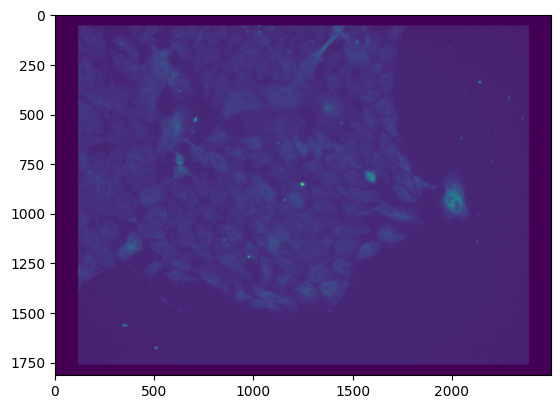

In [19]:
im = skimage.io.imread('/scr/yren/example_img_well1_filed3.png')
print(im.shape)
plt.imshow(im[:,:,0])

In [20]:
probabilities = model.predict(im[:,:,0], stride=1, step=STEP, batch_size=BATCH_SIZE)

100%|██████████| 98/98 [05:01<00:00,  3.08s/it]
/scr/yren/micronuclei-detection/microdet/mnmodel.py:336: RuntimeWarning: invalid value encountered in divide
  probabilities = probabilities/counts


(2, 1814, 2500)


Text(0.5, 1.0, 'Micronuclei Prediction')

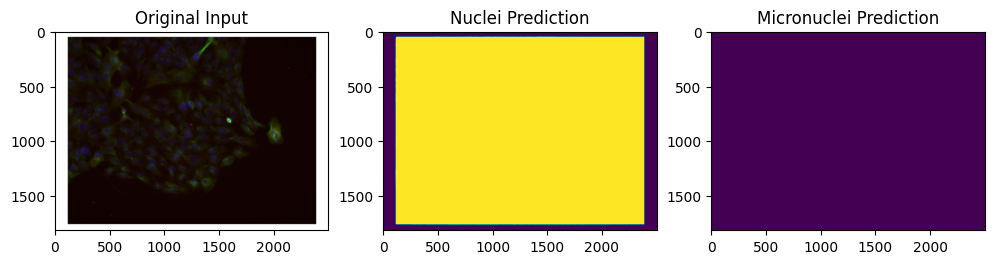

In [22]:
print(probabilities.shape)
nuc_pred = probabilities[1,:,:] > 0.5
mic_pred = probabilities[0,:,:] > 0.5

fig, axs = plt.subplots(1,3,figsize=(12,12))
axs[0].imshow(im)
axs[0].set_title('Original Input')

axs[1].imshow(nuc_pred)
axs[1].set_title('Nuclei Prediction')

axs[2].imshow(mic_pred)
axs[2].set_title('Micronuclei Prediction')

In [27]:
np.unique(probabilities[0,:,:])


array([ 0., nan], dtype=float32)

In [ ]:
validation_file = 'C2-20X_c0-DAPI-GFP_B3_Tile-16.phenotype_outlines.png'
imid = validation_file.split('.')[0]

im = mnds.read_image(DIRECTORY, imid, 'phenotype.tif', scale=SCALE_FACTOR)
im = np.array((im - np.min(im))/(np.max(im) - np.min(im)), dtype="float32")

probabilities = model.predict(im, stride=1, step=STEP, batch_size=BATCH_SIZE)
filename = predictions_dir + validation_file.replace('phenotype_outlines.png','_probabilities')

# Save Predictions

In [ ]:
mn_pred = mn_pred = probabilities[0,:,:] > THRESHOLD
np.save(filename, mn_pred)

In [ ]:
input = skimage.io.imread(f'{os.getcwd()}/dataset_v2/{imid}.phenotype.tif')

fig, ax = plt.subplots(1,3,figsize=(10,6))
for i in range(2):
    ax[i].get_xaxis().set_visible(False)
    ax[i].get_yaxis().set_visible(False)

ax[0].imshow(input)
ax[0].set_title('Original Input')
ax[1].imshow(mn_pred)
ax[1].set_title('Our Model Prediction')